## 0. Validación dataset final

In [9]:
import pandas as pd
import numpy as np
from pathlib import Path

DATA_DIR = Path("/kaggle/input/datasets/tazana/deeplearningfinal-data/processed")

X = pd.read_csv(DATA_DIR / "X_multimodal.csv")
y = pd.read_csv(DATA_DIR / "y_target_any_semen_abnormality.csv")
y = y.iloc[:, 0].astype(int)

print("X original:", X.shape)
print("y:", y.shape)

# Revisar sufijos _x/_y
suffix_cols = [c for c in X.columns if c.endswith("_x") or c.endswith("_y")]

print("Columnas con sufijo _x/_y:", len(suffix_cols))
print(suffix_cols)

cols_to_drop = []
rename_map = {}

for col in X.columns:
    if col.endswith("_x"):
        base = col[:-2]
        pair = base + "_y"

        if pair in X.columns:
            x_values = pd.to_numeric(
                X[col].astype(str).str.replace(",", ".", regex=False),
                errors="coerce"
            )
            y_values = pd.to_numeric(
                X[pair].astype(str).str.replace(",", ".", regex=False),
                errors="coerce"
            )

            if np.allclose(x_values, y_values, equal_nan=True):
                cols_to_drop.append(pair)
                rename_map[col] = base
                print(f"Duplicado confirmado: {col} / {pair} -> se conserva {base}")
            else:
                print(f"Advertencia: {col} y {pair} NO son iguales. Revisar manualmente.")

X = X.drop(columns=cols_to_drop)
X = X.rename(columns=rename_map)

# Convertir todo X a numérico
for col in X.columns:
    if X[col].dtype == "object":
        X[col] = (
            X[col]
            .astype(str)
            .str.strip()
            .str.replace(",", ".", regex=False)
        )

    X[col] = pd.to_numeric(X[col], errors="coerce")

print("\nX limpio:", X.shape)
print("y:", y.shape)

print("\nTipos de datos:")
print(X.dtypes.value_counts())

print("\nColumnas no numéricas:")
print(X.select_dtypes(exclude=["number"]).columns.tolist())

print("\nMissing values:")
display(
    X.isna()
    .mean()
    .sort_values(ascending=False)
    .head(30)
)

print("\nTarget distribution:")
print(y.value_counts())
print(y.value_counts(normalize=True))

X original: (85, 76)
y: (85,)
Columnas con sufijo _x/_y: 8
['video_long_track_ratio_x', 'video_fast_track_ratio_x', 'video_low_movement_track_ratio_x', 'video_progressive_like_ratio_x', 'video_long_track_ratio_y', 'video_fast_track_ratio_y', 'video_low_movement_track_ratio_y', 'video_progressive_like_ratio_y']
Duplicado confirmado: video_long_track_ratio_x / video_long_track_ratio_y -> se conserva video_long_track_ratio
Duplicado confirmado: video_fast_track_ratio_x / video_fast_track_ratio_y -> se conserva video_fast_track_ratio
Duplicado confirmado: video_low_movement_track_ratio_x / video_low_movement_track_ratio_y -> se conserva video_low_movement_track_ratio
Duplicado confirmado: video_progressive_like_ratio_x / video_progressive_like_ratio_y -> se conserva video_progressive_like_ratio

X limpio: (85, 72)
y: (85,)

Tipos de datos:
float64    67
int64       5
Name: count, dtype: int64

Columnas no numéricas:
[]

Missing values:


participant_abstinence_timedays                     0.011765
participant_body_mass_index_kg_m2                   0.000000
participant_age_years                               0.000000
serum_serum_c14_0_myristic_acid                     0.000000
serum_serum_c16_0_palmitic_acid                     0.000000
serum_serum_c16_1_palmitoleic_acid                  0.000000
serum_serum_c18_0_stearic_acid                      0.000000
serum_serum_c18_1_n_9_oleic_acid                    0.000000
serum_serum_total_c18_1                             0.000000
serum_serum_c18_2_n_6_linoleic_acid_la              0.000000
serum_serum_c18_3_n_6_gamma_linoleic_acid_gla       0.000000
serum_serum_c20_1_n_9                               0.000000
serum_serum_c20_2_n_6                               0.000000
serum_serum_c20_3_n_6                               0.000000
serum_serum_c20_4_n_6                               0.000000
serum_serum_c20_5_n_3_eicosapentaenoic_acid_epa     0.000000
serum_serum_c22_5_n_3_do


Target distribution:
target_any_semen_abnormality
1    59
0    26
Name: count, dtype: int64
target_any_semen_abnormality
1    0.694118
0    0.305882
Name: proportion, dtype: float64


### Separar grupos de features

In [10]:
clinical_cols = [
    c for c in X.columns
    if not c.startswith("video_")
]

video_cols = [
    c for c in X.columns
    if c.startswith("video_")
]

feature_sets = {
    "clinical_only": clinical_cols,
    "video_only": video_cols,
    "multimodal": clinical_cols + video_cols,
}

for name, cols in feature_sets.items():
    print(name, len(cols))

clinical_only 50
video_only 22
multimodal 72


## 1. Modelos baseline

In [11]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import make_scorer, balanced_accuracy_score, f1_score, roc_auc_score, average_precision_score

RANDOM_STATE = 42

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    "balanced_accuracy": "balanced_accuracy",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
    "precision": "precision",
    "recall": "recall",
}


models = {
    "dummy_most_frequent": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", DummyClassifier(strategy="most_frequent"))
    ]),

    "dummy_stratified": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", DummyClassifier(strategy="stratified", random_state=RANDOM_STATE))
    ]),

    "logistic_regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=RANDOM_STATE
        ))
    ]),

    "random_forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=3,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ))
    ]),

    "gradient_boosting": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", GradientBoostingClassifier(
            random_state=RANDOM_STATE
        ))
    ]),

    "svm_rbf": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", SVC(
            kernel="rbf",
            class_weight="balanced",
            probability=True,
            random_state=RANDOM_STATE
        ))
    ]),

    "mlp_sklearn": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", MLPClassifier(
            hidden_layer_sizes=(64, 32),
            activation="relu",
            alpha=1e-3,
            learning_rate_init=1e-3,
            max_iter=1000,
            early_stopping=True,
            random_state=RANDOM_STATE
        ))
    ]),
}

## 2. Evaluación con cross-validation

In [12]:
seeds = [0, 1, 2, 3, 4, 42, 123, 2024, 2025, 2026]

repeated_results = []

for seed in seeds:
    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=seed
    )

    for feature_set_name, cols in feature_sets.items():
        X_subset = X[cols].copy()

        for model_name, model in models.items():
            print(f"Seed={seed} | {feature_set_name} | {model_name}")

            cv_results = cross_validate(
                model,
                X_subset,
                y,
                cv=cv,
                scoring=scoring,
                return_train_score=False,
                n_jobs=-1
            )

            for fold_idx in range(5):
                row = {
                    "seed": seed,
                    "fold": fold_idx,
                    "feature_set": feature_set_name,
                    "model": model_name,
                }

                for metric_name in scoring.keys():
                    row[metric_name] = cv_results[f"test_{metric_name}"][fold_idx]

                repeated_results.append(row)

repeated_results_df = pd.DataFrame(repeated_results)

Seed=0 | clinical_only | dummy_most_frequent
Seed=0 | clinical_only | dummy_stratified
Seed=0 | clinical_only | logistic_regression
Seed=0 | clinical_only | random_forest
Seed=0 | clinical_only | gradient_boosting
Seed=0 | clinical_only | svm_rbf
Seed=0 | clinical_only | mlp_sklearn
Seed=0 | video_only | dummy_most_frequent
Seed=0 | video_only | dummy_stratified
Seed=0 | video_only | logistic_regression
Seed=0 | video_only | random_forest
Seed=0 | video_only | gradient_boosting
Seed=0 | video_only | svm_rbf
Seed=0 | video_only | mlp_sklearn
Seed=0 | multimodal | dummy_most_frequent
Seed=0 | multimodal | dummy_stratified
Seed=0 | multimodal | logistic_regression
Seed=0 | multimodal | random_forest
Seed=0 | multimodal | gradient_boosting
Seed=0 | multimodal | svm_rbf
Seed=0 | multimodal | mlp_sklearn
Seed=1 | clinical_only | dummy_most_frequent
Seed=1 | clinical_only | dummy_stratified
Seed=1 | clinical_only | logistic_regression
Seed=1 | clinical_only | random_forest
Seed=1 | clinical_o

In [13]:
repeated_summary_df = (
    repeated_results_df
    .groupby(["feature_set", "model"])
    .agg(
        balanced_accuracy_mean=("balanced_accuracy", "mean"),
        balanced_accuracy_std=("balanced_accuracy", "std"),
        f1_mean=("f1", "mean"),
        f1_std=("f1", "std"),
        roc_auc_mean=("roc_auc", "mean"),
        roc_auc_std=("roc_auc", "std"),
        average_precision_mean=("average_precision", "mean"),
        average_precision_std=("average_precision", "std"),
        precision_mean=("precision", "mean"),
        precision_std=("precision", "std"),
        recall_mean=("recall", "mean"),
        recall_std=("recall", "std"),
    )
    .reset_index()
    .sort_values("roc_auc_mean", ascending=False)
)

display(repeated_summary_df.round(3))

,feature_set,model,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std,precision_mean,precision_std,recall_mean,recall_std
17,video_only,logistic_regression,0.812,0.102,0.856,0.075,0.920,0.067,0.966,0.029,0.914,0.080,0.817,0.118
20,video_only,svm_rbf,0.766,0.098,0.816,0.085,0.885,0.067,0.953,0.029,0.888,0.081,0.770,0.135
13,multimodal,svm_rbf,0.793,0.111,0.864,0.061,0.884,0.087,0.946,0.046,0.888,0.091,0.853,0.094
12,multimodal,random_forest,0.773,0.118,0.875,0.058,0.870,0.090,0.942,0.042,0.863,0.089,0.900,0.095
19,video_only,random_forest,0.682,0.124,0.801,0.073,0.851,0.094,0.939,0.041,0.817,0.091,0.800,0.118
10,multimodal,logistic_regression,0.747,0.090,0.813,0.062,0.844,0.078,0.935,0.037,0.875,0.088,0.776,0.117
5,clinical_only,random_forest,0.736,0.122,0.860,0.064,0.816,0.126,0.897,0.080,0.833,0.087,0.899,0.092
11,multimodal,mlp_sklearn,0.693,0.125,0.834,0.077,0.814,0.132,0.915,0.064,0.807,0.081,0.870,0.103
6,clinical_only,svm_rbf,0.754,0.112,0.855,0.066,0.814,0.138,0.900,0.087,0.852,0.082,0.868,0.101
16,video_only,gradient_boosting,0.723,0.124,0.837,0.082,0.799,0.113,0.896,0.068,0.831,0.083,0.855,0.121


## 3. Guardar resultados

In [14]:
RESULTS_DIR = Path("/kaggle/working")

repeated_results_df.to_csv(
    RESULTS_DIR / "model_results_repeated_cv_all_folds.csv",
    index=False
)

repeated_summary_df.to_csv(
    RESULTS_DIR / "model_results_repeated_cv_summary.csv",
    index=False
)

print("Resultados repetidos guardados en:", RESULTS_DIR / "model_results_repeated_cv_all_folds.csv")
print("Resultados resumidos guardados en:", RESULTS_DIR / "model_results_repeated_cv_summary.csv")

Resultados repetidos guardados en: /kaggle/working/model_results_repeated_cv_all_folds.csv
Resultados resumidos guardados en: /kaggle/working/model_results_repeated_cv_summary.csv


## 4. Gráficas comparativas

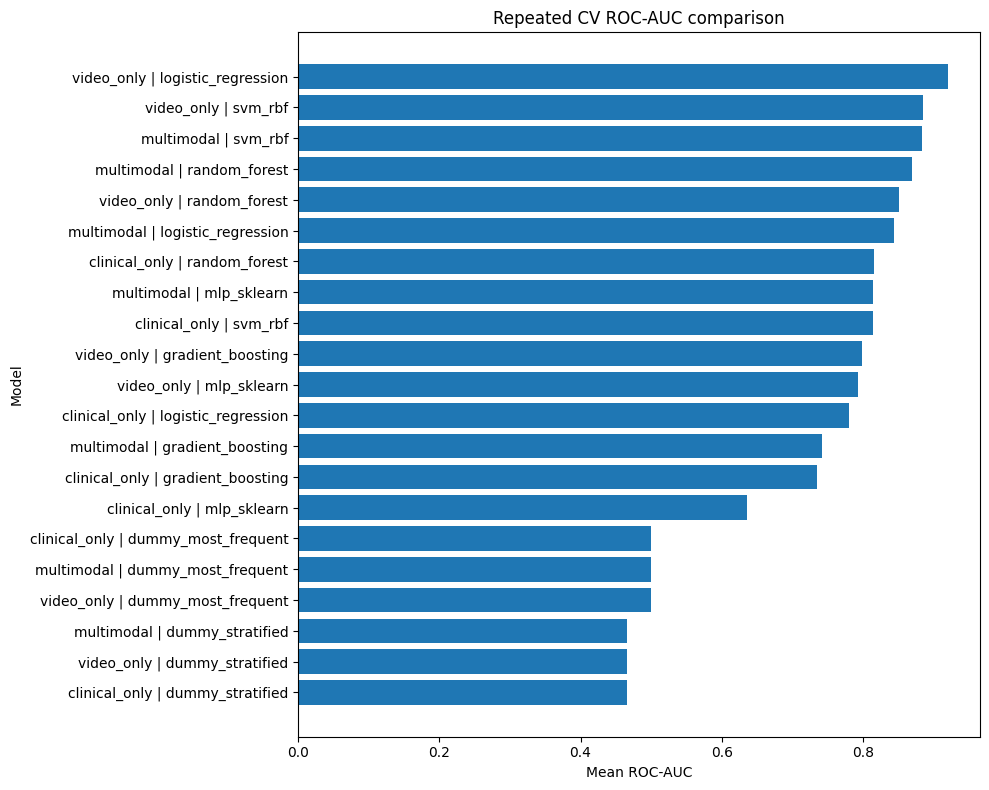

In [16]:
import matplotlib.pyplot as plt

plot_df = repeated_summary_df.copy()
plot_df["label"] = plot_df["feature_set"] + " | " + plot_df["model"]

plot_df = plot_df.sort_values("roc_auc_mean", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(plot_df["label"], plot_df["roc_auc_mean"])
plt.xlabel("Mean ROC-AUC")
plt.ylabel("Model")
plt.title("Repeated CV ROC-AUC comparison")
plt.tight_layout()
plt.show()

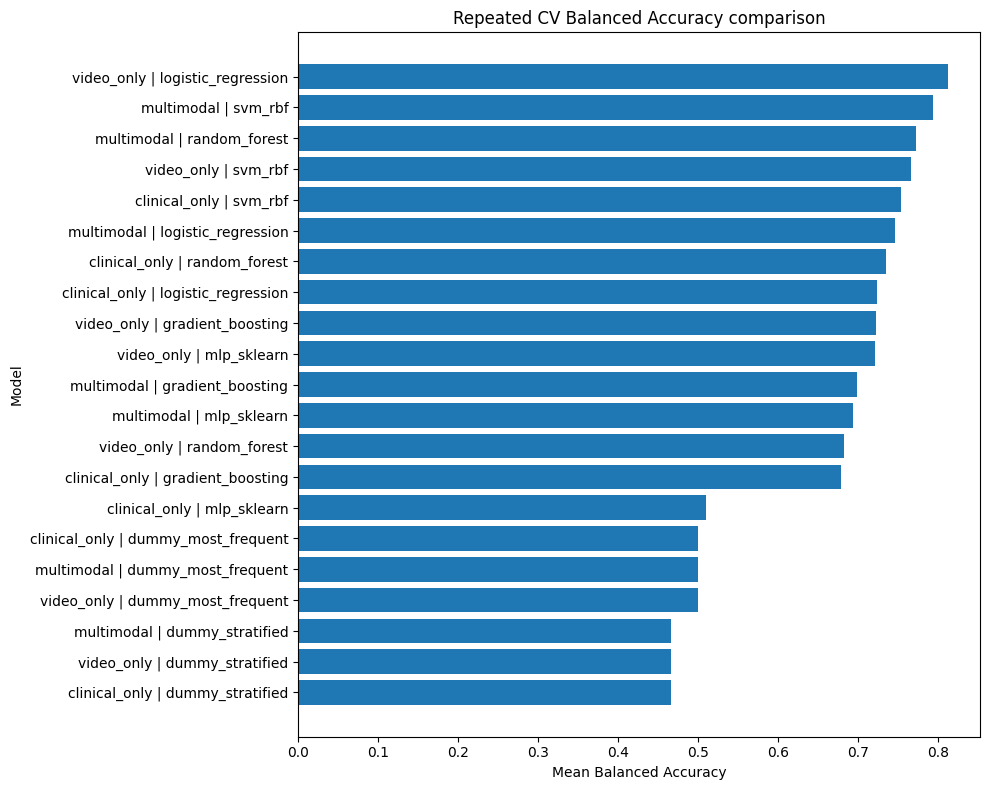

In [17]:
plot_df = repeated_summary_df.copy()
plot_df["label"] = plot_df["feature_set"] + " | " + plot_df["model"]

plot_df = plot_df.sort_values("balanced_accuracy_mean", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(plot_df["label"], plot_df["balanced_accuracy_mean"])
plt.xlabel("Mean Balanced Accuracy")
plt.ylabel("Model")
plt.title("Repeated CV Balanced Accuracy comparison")
plt.tight_layout()
plt.show()

## 5. Extraer coeficientes del mejor modelo
Con base en los resultados anteriores, el mejor modelo fue el de regresión logística usando solo las features de video. Eso puede ser debido al tamaño tan pequeño del dataset (85 muestras). Idealmente, se buscaba una aproximación MLP, pero puede ser que este dataset no sea adecuado para ello. De igual forma se va a tratar de hacer, pero por el momento vamos a tomar los coeficientes de "video_only + logistic_regression".

In [18]:
best_feature_set_name = "video_only"
best_model_name = "logistic_regression"

best_cols = feature_sets[best_feature_set_name]
best_model = models[best_model_name]

best_model.fit(X[best_cols], y)

coef = best_model.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "feature": best_cols,
    "coefficient": coef,
    "abs_coefficient": np.abs(coef),
}).sort_values("abs_coefficient", ascending=False)

display(coef_df.head(20))

coef_df.to_csv(
    RESULTS_DIR / "best_model_logistic_coefficients.csv",
    index=False
)

,feature,coefficient,abs_coefficient
19,video_low_movement_track_ratio,1.517260,1.517260
21,video_key,-1.333323,1.333323
20,video_progressive_like_ratio,0.685599,0.685599
4,video_mean_duration_s,0.533195,0.533195
9,video_speed_std_px_s,0.524603,0.524603
18,video_fast_track_ratio,0.477939,0.477939
16,video_mean_area_norm,0.475979,0.475979
6,video_mean_speed_px_s,-0.459427,0.459427
3,video_p90_track_frames,0.445010,0.445010
0,video_n_tracks,0.430455,0.430455
